# Laboratorul 10 -> Reinforcement Learning (The Cliff Walker's Dilemma)

The Cliff Walker's Dilemma. Un agent trebuie să traverseze o grilă de la punctul de Start până la punctul Goal. De-a lungul marginii inferioare se află o prăpastie (cliff): orice pas în prăpastie penalizează sever agentul și îl trimite înapoi la Start. Agentul nu cunoaște harta - trebuie să învețe din experiență.

Cerinte:
1. Implementarea mediului deterministic
2. Implementare SARSA
3. Implementare Q-learning
4. Experimentul central - divergenta politicilor:
    - Rulați ambii algoritmi și generați:
        - graficul sumei recompenselor per episod (mediat pe o fereastră mobilă de 10 episoade), pentru ambii algoritmi pe aceeași figură
        - vizualizarea politicii greedy învățate de fiecare algoritm pe grilă (săgeți sau simboluri pentru fiecare celulă)

    - Răspundeți în scris (200-400 cuvinte) la:
        - Care algoritm învață un drum mai scurt în politica greedy finală? Care algoritm obține o sumă cumulată mai mare în timpul antrenării?
        - De ce cei doi algoritmi converg la politici diferite? Răspunsul trebuie să facă referire explicită la diferența dintre ținte (max vs. acțiune eșantionată) și la conceptul on-policy vs. off-policy.
        - De ce nu există o contradicție între (a) și răspunsul la (b)?

5. Provocare - reward shaping. Modificați doar funcția de recompensă (NU hiperparametrii, NU algoritmul) astfel încât ambii algoritmi să conveargă la aceeași politică greedy. Există mai multe soluții valide. Justificați în scris de ce modificarea voastră forțează echivalența, cu referire la mecanismul identificat la cerința 3.
6. Provocare - ε-scheduling. Reveniți la funcția de recompensă originală. Proiectați o schemă de descreștere a lui ε (ex. ε_t = ε_0 · decay^t, sau liniară) astfel încât politica greedy finală a lui SARSA să coincidă cu cea învățată de Q-learning. Argumentați: ce se întâmplă cu ținta SARSA atunci când ε → 0?
7. Reflecție teoretică (răspunsuri scurte, 2-4 propoziții fiecare):
    - Ce se întâmplă dacă setați ε = 0 de la început pentru Q-learning? Dar pentru SARSA? De ce?
    - Dacă γ < 1 (ex. γ = 0.9), cum se schimbă preferința fiecărui algoritm pentru drumul scurt vs. drumul sigur? Argumentați.
    - Dați un exemplu din lumea reală (nu joc de grilă) în care ați prefera SARSA în locul Q-learning și explicați de ce.


### 1. Mediu deterministic

In [9]:
from CliffWalkingEnv import CliffWalkingEnv

environment = CliffWalkingEnv(-1,-100,0)

### 2. Implementare SARSA

In [10]:
import numpy as np
import random

# se utilizeaza:
# tabel Q (action-state value function) de dimensiune |S| x |A| (S - states, A - actions)
state_dimension = environment.rows * environment.columns
action_dimension = 4

Q_SARSA = np.zeros((state_dimension, action_dimension))
episodes = 500

# se plaseaza agentul pe pozitia de start
environment.reset()

# hiperparametrii: alpha = 0.1, gamma = 1.0, epsilon = 0.1, 500 episoade
alpha = 0.1
discount = 1.0
epsilon = 0.1

def implement_SARSA(alpha,discount,epsilon,episodes,Q_SARSA,environment):
    rewards_SARSA = np.zeros(episodes)

    for episode in range(episodes):
        environment.reset()
        done = False

        # politica de explorare este epsilon-greedy pentru determinarea actiunii curente
        if random.random() < epsilon:
            # exploreaza -> posibil reward pe viitor
            action = random.randint(0,action_dimension-1)
        else:
            # ia maximul pe care-l cunoaste -> reward pe moment
            action = np.argmax(Q_SARSA[environment.render()])

        while not done:
            current_state = environment.render()
            next_state, reward, done = environment.step(action)

            rewards_SARSA[episode] += reward

            # politica de explorare este epsilon-greedy pentru determinarea actiunii urmatoare
            if random.random() < epsilon:
                # exploreaza -> posibil reward pe viitor
                next_action = random.randint(0,action_dimension-1)
            else:
                # ia maximul pe care-l cunoaste -> reward pe moment
                next_action = np.argmax(Q_SARSA[next_state])

            # logica SARSA
            Q_SARSA[current_state][action] += alpha * (reward + discount * Q_SARSA[next_state][next_action] - Q_SARSA[current_state][action])
            action = next_action

    return rewards_SARSA, Q_SARSA

rewards_SARSA, Q_SARSA = implement_SARSA(alpha,discount,epsilon,episodes,Q_SARSA,environment)

### 3. Implementare Q-learning

In [11]:
Q_learning = np.zeros((state_dimension, action_dimension))
environment.reset()


def implement_Q_learning(alpha,discount,epsilon,episodes,Q_learning,environment):
    rewards_Q_learning = np.zeros(episodes)

    for episode in range(episodes):
        environment.reset()
        done = False

        while not done:
            current_state = environment.render()
            # politica de explorare este epsilon-greedy pentru determinarea actiunii curente
            if random.random() < epsilon:
                # exploreaza -> posibil reward pe viitor
                action = random.randint(0,action_dimension-1)
            else:
                # ia maximul pe care-l cunoaste -> reward pe moment
                action = np.argmax(Q_learning[environment.render()])

            next_state, reward, done = environment.step(action)
            rewards_Q_learning[episode] += reward

            # logica Q-learning
            Q_learning[current_state][action] += alpha * (reward + discount * np.max(Q_learning[next_state]) - Q_learning[current_state][action])

    return rewards_Q_learning, Q_learning

rewards_Q_learning,Q_learning = implement_Q_learning(alpha,discount,epsilon,episodes,Q_learning,environment)

### 4. Experimentul central - divergenta politicilor

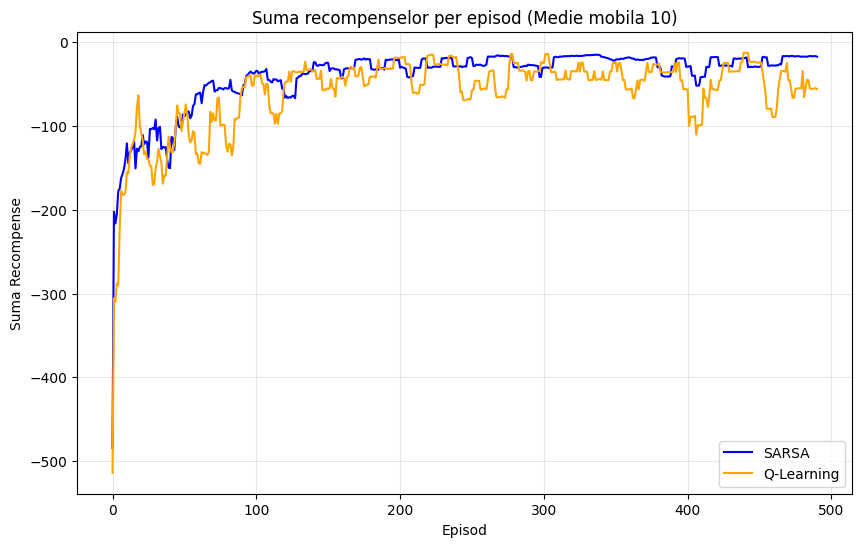


--- Politica SARSA (Safe) ---
|  →  |  →  |  →  |  →  |  →  |  ↓  |  →  |  →  |  →  |  ↓  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ↑  |  ↑  |  →  |  ↑  |  ↑  |  ↑  |  →  |  ←  |  ↑  |  ↑  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ↑  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  G  |
-------------------------------------------------------------------------

--- Politica Q-Learning (Optimal) ---
|  ↑  |  ↓  |  ↑  |  ↓  |  ↓  |  →  |  →  |  ←  |  →  |  ←  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ←  |  →  |  ↑  |  →  |  ←  |  →  |  →  |  ↓  |  →  |  →  |  ↓  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  

In [12]:
import matplotlib.pyplot as plt

def plot_rewards(sarsa_rewards, q_learning_rewards, window=10):
    def moving_average(data, w):
        return np.convolve(data, np.ones(w), 'valid') / w

    plt.figure(figsize=(10, 6))
    plt.plot(moving_average(sarsa_rewards, window), label="SARSA", color='blue')
    plt.plot(moving_average(q_learning_rewards, window), label="Q-Learning", color='orange')

    plt.title(f"Suma recompenselor per episod (Medie mobila {window})")
    plt.xlabel("Episod")
    plt.ylabel("Suma Recompense")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_rewards(rewards_SARSA, rewards_Q_learning)



def visualize_policy(Q, title="Politica invatata"):
    rows, cols = 4, 12
    # actiuni: 0 - UP, 1 - DOWN, 2 - RIGHT, 3 LEFT
    symbols = {0: "↑", 1: "↓", 2: "→", 3: "←"}

    print(f"\n--- {title} ---")
    for row in range(rows):
        row_str = "|"
        for current_col in range(cols):
            state = row * cols + current_col

            # se marcheaza zonele speciale
            if (row, current_col) == (3, 11):
                # goal
                row_str += "  G  |"
            elif row == 3 and 1 <= current_col <= 10:
                # cliff
                row_str += "  X  |"
            else:
                best_action = np.argmax(Q[state])
                row_str += f"  {symbols[best_action]}  |"
        print(row_str)
        print("-" * (cols * 6 + 1))

visualize_policy(Q_SARSA, "Politica SARSA (Safe)")
visualize_policy(Q_learning, "Politica Q-Learning (Optimal)")

### 5. Reward shaping

In [13]:
new_environment = CliffWalkingEnv(-70,-100,0)

Q_SARSA = np.zeros((state_dimension, action_dimension))
Q_learning = np.zeros((state_dimension, action_dimension))

# se implementeaza ambele metode
_,Q_learning = implement_Q_learning(alpha,discount,epsilon,episodes,Q_learning,new_environment)
_,Q_SARSA = implement_SARSA(alpha,discount,epsilon,episodes,Q_SARSA,new_environment)

# se vizualizeaza politicile invatate
visualize_policy(Q_SARSA, "Politica SARSA (Safe)")
visualize_policy(Q_learning, "Politica Q-Learning (Optimal)")



--- Politica SARSA (Safe) ---
|  →  |  →  |  ↓  |  →  |  ↓  |  ↓  |  →  |  →  |  ←  |  →  |  ↓  |  ↓  |
-------------------------------------------------------------------------
|  ←  |  →  |  →  |  →  |  →  |  →  |  ↓  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ↑  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  G  |
-------------------------------------------------------------------------

--- Politica Q-Learning (Optimal) ---
|  →  |  →  |  ←  |  →  |  →  |  ↑  |  →  |  →  |  ↓  |  ↓  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  ↓  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  

### 6. Epsilon Scheduling

Implementare SARSA si Q-learning, conform schimbarii epsilon

In [14]:
# se foloseste environmentul initial (se pastreaza functia de reward)

Q_SARSA = np.zeros((state_dimension, action_dimension))
Q_learning = np.zeros((state_dimension, action_dimension))

# se implementeaza SARSA
for episode in range(episodes):
    environment.reset()
    done = False

    initial_epsilon = 0.2
    decay = 0.5

    epsilon = initial_epsilon

    # politica de explorare este epsilon-greedy pentru determinarea actiunii curente
    if random.random() < epsilon:
        # exploreaza -> posibil reward pe viitor
        action = random.randint(0,action_dimension-1)
    else:
        # ia maximul pe care-l cunoaste -> reward pe moment
        action = np.argmax(Q_SARSA[environment.render()])

    while not done:
        current_state = environment.render()
        next_state, reward, done = environment.step(action)

        rewards_SARSA[episode] += reward

        # se modifica epsilon
        epsilon = initial_epsilon * decay
        decay *= decay

        # politica de explorare este epsilon-greedy pentru determinarea actiunii urmatoare
        if random.random() < epsilon:
            # exploreaza -> posibil reward pe viitor
            next_action = random.randint(0,action_dimension-1)
        else:
            # ia maximul pe care-l cunoaste -> reward pe moment
            next_action = np.argmax(Q_SARSA[next_state])

        # logica SARSA
        Q_SARSA[current_state][action] += alpha * (reward + discount * Q_SARSA[next_state][next_action] - Q_SARSA[current_state][action])
        action = next_action


# se implementeza Q_learning
for episode in range(episodes):
    environment.reset()
    done = False

    initial_epsilon = 0.2
    decay = 0.5

    epsilon = initial_epsilon

    while not done:
        current_state = environment.render()
        # politica de explorare este epsilon-greedy pentru determinarea actiunii curente
        if random.random() < epsilon:
            # exploreaza -> posibil reward pe viitor
            action = random.randint(0,action_dimension-1)
        else:
            # ia maximul pe care-l cunoaste -> reward pe moment
            action = np.argmax(Q_learning[environment.render()])

        # se modifica epsilon
        epsilon = initial_epsilon * decay
        decay *= decay

        next_state, reward, done = environment.step(action)
        rewards_Q_learning[episode] += reward

        # logica Q-learning
        Q_learning[current_state][action] += alpha * (reward + discount * np.max(Q_learning[next_state]) - Q_learning[current_state][action])


Vizualizarea politicilor

In [15]:
visualize_policy(Q_SARSA, "Politica SARSA (Safe)")
visualize_policy(Q_learning, "Politica Q-Learning (Optimal)")


--- Politica SARSA (Safe) ---
|  →  |  →  |  →  |  →  |  ↓  |  →  |  →  |  →  |  →  |  →  |  ↓  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |  ↓  |  ↓  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ↑  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  G  |
-------------------------------------------------------------------------

--- Politica Q-Learning (Optimal) ---
|  ↑  |  ↑  |  →  |  ↓  |  ↓  |  →  |  ↑  |  ↑  |  →  |  →  |  ↑  |  ↓  |
-------------------------------------------------------------------------
|  →  |  ↑  |  →  |  →  |  →  |  ↑  |  ↓  |  →  |  ↑  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  

Test pentru epsilon 0 -> Agentul este extrem de preventiv si nu exploreaza deloc

In [16]:
Q_SARSA = np.zeros((state_dimension, action_dimension))
Q_learning = np.zeros((state_dimension, action_dimension))

# se implementeaza ambele metode
_,Q_learning = implement_Q_learning(alpha,discount,0,episodes,Q_learning,environment)
_,Q_SARSA = implement_SARSA(alpha,discount,0,episodes,Q_SARSA,environment)

# se vizualizeaza politicile invatate
visualize_policy(Q_SARSA, "Politica SARSA (Safe)")
visualize_policy(Q_learning, "Politica Q-Learning (Optimal)")


--- Politica SARSA (Safe) ---
|  ↑  |  ←  |  ←  |  →  |  →  |  ↑  |  →  |  ↓  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  ↑  |  ↓  |  ↓  |  →  |  →  |  ↓  |  →  |  ↓  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  →  |  ↓  |
-------------------------------------------------------------------------
|  ↑  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  X  |  G  |
-------------------------------------------------------------------------

--- Politica Q-Learning (Optimal) ---
|  ↓  |  ↑  |  →  |  ←  |  ↑  |  →  |  ↓  |  ←  |  →  |  ↓  |  →  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  ↑  |  →  |  →  |  →  |  →  |  ↑  |  →  |  ↓  |  ↓  |  ↓  |
-------------------------------------------------------------------------
|  →  |  →  |  →  |  →  |  →  |  →  |  →  